In [1]:
import pandas as pd

df_master = pd.read_csv("../havier/data/clean/features/hey_merge_features_limpio.csv")

In [2]:
# Obtener la lista completa de columnas
lista_columnas = df_master.columns.tolist()

# Imprimir la lista
print(lista_columnas)

['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo', 'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro', 'nomina_domiciliada', 'canal_apertura', 'score_buro', 'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10', 'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro', 'num_productos_activos', 'patron_uso_atipico', 'total_productos', 'productos_activos', 'productos_cancelados', 'productos_suspendidos', 'productos_en_revision', 'total_creditos', 'total_tarjetas', 'total_seguros', 'total_cuentas', 'total_inversiones', 'limite_credito_total', 'saldo_total_productos', 'utilizacion_promedio', 'tasa_interes_promedio', 'mensualidad_total', 'producto_principal', 'estatus_principal', 'fecha_producto_mas_reciente', 'fecha_ultimo_movimiento_producto', 'total_transacciones', 'monto_total', 'monto_promedio', 'monto_maximo', 'transacciones_completadas', 'transacciones_no_procesadas', 'transacciones_en_disputa', 'transacciones_revertidas', 'o

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Proteger el ID y limpiar columnas de fechas
# (Las fechas como texto explotan al hacer encoding, mejor quitarlas o convertirlas a días)
columnas_a_ignorar = [
    # 1. IDs y Fechas (Ya las tenías)
    'user_id', 
    'ultima_transaccion', 
    'primera_transaccion', 
    'fecha_producto_mas_reciente', 
    'fecha_ultimo_movimiento_producto',
    
    # 2. Alta Cardinalidad / Textos
    'ciudad',  
    'estado',
    'ciudad_principal',
    'insight_transaccional', 
    
    # 3. Redundancias Directas
    'num_productos_activos',
    'es_usuario_atipico',
    'nivel_riesgo_transaccional',
    'nivel_oportunidad_transaccional',
    
    # 4. Multicolinealidad (Quitamos conteos porque ya tienes las tasas)
    'transacciones_no_procesadas',
    'transacciones_en_disputa',
    'transacciones_revertidas'
]

df_ids = df_master[['user_id']] # Guardamos los IDs a salvo
df_features = df_master.drop(columns=columnas_a_ignorar, errors='ignore')

# 2. Identificar tipos de variables
cols_numericas = df_features.select_dtypes(include=['int64', 'float64']).columns
cols_categoricas = df_features.select_dtypes(include=['object', 'bool']).columns

print(f"Variables numéricas: {len(cols_numericas)} | Variables categóricas/booleanas: {len(cols_categoricas)}")

# 3. One-Hot Encoding (Convertir texto/bool a columnas de 0s y 1s)
# drop_first=True evita la trampa de las variables dummy (multicolinealidad perfecta)
df_encoded = pd.get_dummies(df_features, columns=cols_categoricas, drop_first=True)
print(f"Dimensiones después del encoding: {df_encoded.shape}")

# 4. StandardScaler (Centrar en 0 y varianza de 1)
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_encoded)

# 5. Reconstruir el DataFrame limpio y escalado
df_scaled = pd.DataFrame(df_scaled_array, columns=df_encoded.columns)
df_listo_para_ml = pd.concat([df_ids, df_scaled], axis=1)

print("¡Preprocesamiento completado con éxito!")

Variables numéricas: 44 | Variables categóricas/booleanas: 18
Dimensiones después del encoding: (15025, 96)
¡Preprocesamiento completado con éxito!


C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_15048\3973818643.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_features.select_dtypes(include=['object', 'bool']).columns


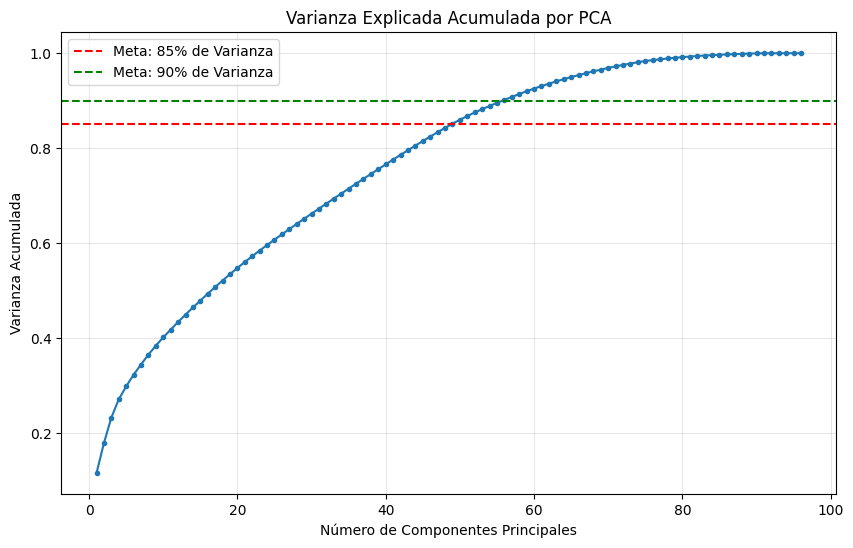

⚡ Para retener el 85% del comportamiento original, necesitas: 49 componentes.
⚡ Para retener el 90% del comportamiento original, necesitas: 56 componentes.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. Ajustar el PCA con tus 96 variables procesadas
pca_exploratorio = PCA()
pca_exploratorio.fit(df_scaled) # Utilizamos tu dataframe ya escalado

# 2. Calcular la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_exploratorio.explained_variance_ratio_)

# 3. Graficar la curva del "Codo"
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='.', linestyle='-')

# Líneas de referencia para nuestras metas
plt.axhline(y=0.85, color='r', linestyle='--', label='Meta: 85% de Varianza')
plt.axhline(y=0.90, color='g', linestyle='--', label='Meta: 90% de Varianza')

plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Calcular el número exacto de componentes necesarios
componentes_85 = np.argmax(varianza_acumulada >= 0.85) + 1
componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print(f"⚡ Para retener el 85% del comportamiento original, necesitas: {componentes_85} componentes.")
print(f"⚡ Para retener el 90% del comportamiento original, necesitas: {componentes_90} componentes.")

Dimensiones de la matriz final para K-Means: (15025, 49)


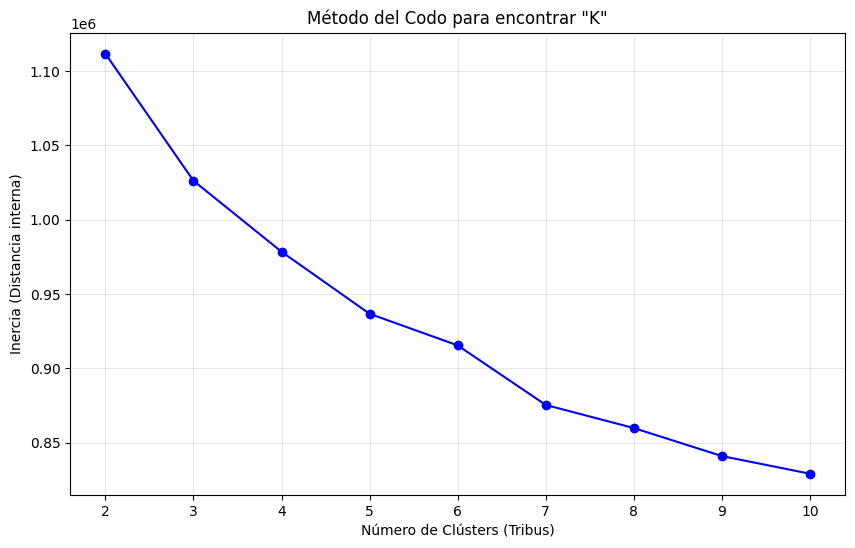

In [5]:
from sklearn.cluster import KMeans

# 1. Aplicar el PCA definitivo con 49 componentes
pca_final = PCA(n_components=49, random_state=42)
df_pca = pca_final.fit_transform(df_scaled)

print(f"Dimensiones de la matriz final para K-Means: {df_pca.shape}")

# 2. Encontrar el número óptimo de clústers (Método del Codo)
inercias = []
rango_clusters = range(2, 11) # Probaremos de 2 a 10 grupos

for k in rango_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inercias.append(kmeans.inertia_)

# 3. Graficar el resultado
plt.figure(figsize=(10, 6))
plt.plot(rango_clusters, inercias, marker='o', linestyle='-', color='b')
plt.title('Método del Codo para encontrar "K"')
plt.xlabel('Número de Clústers (Tribus)')
plt.ylabel('Inercia (Distancia interna)')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# 1. Entrenar el modelo definitivo con 6 tribus
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_final.fit(df_pca)

# 2. Pegar las etiquetas al dataset maestro (el original legible)
df_master['cluster_id'] = kmeans_final.labels_

# 3. Ver cómo se distribuyeron los 15,025 clientes
distribucion = df_master['cluster_id'].value_counts().sort_index()

print("Distribución de clientes por Clúster:")
for cluster, conteo in distribucion.items():
    porcentaje = (conteo / len(df_master)) * 100
    print(f"Clúster {cluster}: {conteo} clientes ({porcentaje:.1f}%)")

Distribución de clientes por Clúster:
Clúster 0: 6081 clientes (40.5%)
Clúster 1: 3829 clientes (25.5%)
Clúster 2: 1789 clientes (11.9%)
Clúster 3: 1853 clientes (12.3%)
Clúster 4: 1473 clientes (9.8%)


In [7]:
# 1. Definir las variables clave que nos cuentan la historia del cliente
columnas_perfil = [
    'antiguedad_dias', 
    'dias_desde_ultimo_login',
    'total_productos',
    'saldo_total_productos', 
    'utilizacion_promedio',
    'total_transacciones', 
    'monto_total',
    'score_buro'
]

# 2. Calcular la media de estas variables por cada clúster
perfil_clusters = df_master.groupby('cluster_id')[columnas_perfil].mean().round(2)

# 3. Mostrar la tabla transpuesta para comparar atributos lado a lado
import pandas as pd
pd.set_option('display.max_columns', None) # Para asegurar que se vean todos los clústers
print("Perfilamiento Promedio por Clúster:")
print(perfil_clusters.T)

Perfilamiento Promedio por Clúster:
cluster_id                       0          1          2         3          4
antiguedad_dias             926.95     964.25     917.81    909.33     946.46
dias_desde_ultimo_login       5.89       7.13      12.00    100.90       7.10
total_productos               2.37       3.35       2.61      1.21       3.23
saldo_total_productos     71487.46  298906.94  110246.98  43770.76  171228.19
utilizacion_promedio          0.15       0.05       0.49      0.03       0.12
total_transacciones          61.20      58.97      44.55     10.94      70.91
monto_total              221508.73  601575.68  162580.52  46179.38  593689.48
score_buro                  612.99     728.06     445.97    538.78     665.80


In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import time

print("Calculando métricas de validación... (Esto puede tardar unos segundos)")
start_time = time.time()

# 1. Silhouette Score
sil_score = silhouette_score(df_pca, kmeans_final.labels_)

# 2. Índice Davies-Bouldin
db_score = davies_bouldin_score(df_pca, kmeans_final.labels_)

# 3. Índice Calinski-Harabasz
ch_score = calinski_harabasz_score(df_pca, kmeans_final.labels_)

end_time = time.time()

print(f"\nResultados de la Evaluación (K=5):")
print("-" * 40)
print(f"1. Silhouette Score:        {sil_score:.4f}")
print(f"2. Davies-Bouldin Index:    {db_score:.4f}")
print(f"3. Calinski-Harabasz Index: {ch_score:.4f}")
print("-" * 40)
print(f"Tiempo de ejecución: {(end_time - start_time):.2f} segundos")

Calculando métricas de validación... (Esto puede tardar unos segundos)

Resultados de la Evaluación (K=5):
----------------------------------------
1. Silhouette Score:        0.1067
2. Davies-Bouldin Index:    2.2515
3. Calinski-Harabasz Index: 1168.8308
----------------------------------------
Tiempo de ejecución: 3.11 segundos


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. Configurar el hardware (Forzar el uso de tu RTX 3060)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Ejecutando en: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# 2. Convertir tu DataFrame escalado a Tensores de PyTorch
X_tensor = torch.FloatTensor(df_scaled.values).to(device)
dataset = TensorDataset(X_tensor, X_tensor) # Input y Output son lo mismo en un Autoencoder
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

# 3. Definir la Arquitectura de la Red Neuronal
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        # El Encoder: Comprime 96 -> 64 -> 32 -> 10 dimensiones
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10) # Este es el 'Latent Space' donde se forman los clústers
        )
        
        # El Decoder: Reconstruye 10 -> 32 -> 64 -> 96 dimensiones
        self.decoder = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# 4. Inicializar el modelo
input_dim = df_scaled.shape[1] # Tus 96 columnas
autoencoder = Autoencoder(input_dim).to(device)

# Función de pérdida (Error Cuadrático Medio) y Optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# 5. Bucle de Entrenamiento (Pre-entrenamiento del DEC)
epochs = 150 # Puedes subirlo a 300 si quieres más precisión, tu GPU lo aguanta

print("\nIniciando pre-entrenamiento del Autoencoder...")
autoencoder.train()
for epoch in range(epochs):
    total_loss = 0
    for batch_x, _ in dataloader:
        optimizer.zero_grad()
        
        # Forward pass
        _, reconstructed = autoencoder(batch_x)
        
        # Calcular el error
        loss = criterion(reconstructed, batch_x)
        
        # Backward pass (Ajustar pesos)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    if (epoch + 1) % 30 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss (MSE): {total_loss/len(dataloader):.4f}')

print("✅ Red Neuronal pre-entrenada con éxito.")

🚀 Ejecutando en: CPU


C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_15048\1745003457.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_tensor = torch.FloatTensor(df_scaled.values).to(device)



Iniciando pre-entrenamiento del Autoencoder...
Epoch [30/150], Loss (MSE): 0.3475
Epoch [60/150], Loss (MSE): 0.3063
Epoch [90/150], Loss (MSE): 0.2925
Epoch [120/150], Loss (MSE): 0.2848
Epoch [150/150], Loss (MSE): 0.2788
✅ Red Neuronal pre-entrenada con éxito.


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Poner la red en modo evaluación y extraer el Espacio Latente
autoencoder.eval() 
with torch.no_grad():
    # Solo pasamos por el 'encoder', ignoramos el 'decoder'
    espacio_latente = autoencoder.encoder(X_tensor).cpu().numpy()

print(f"Dimensiones de la nueva matriz: {espacio_latente.shape}")

# 2. Correr K-Means sobre este nuevo espacio comprimido
# Usamos 5 clústers porque es el número de tribus que descubrimos antes
kmeans_dec = KMeans(n_clusters=5, random_state=42, n_init=10)
etiquetas_dec = kmeans_dec.fit_predict(espacio_latente)

# 3. La hora de la verdad: Evaluar la cohesión
nuevo_sil_score = silhouette_score(espacio_latente, etiquetas_dec)

print("\n--- Resultados de la Fase de Inicialización DEC ---")
print(f"🌟 Nuevo Silhouette Score: {nuevo_sil_score:.4f}")
print("(Recordatorio: Tu score anterior con PCA fue de 0.1067)")

Dimensiones de la nueva matriz: (15025, 10)

--- Resultados de la Fase de Inicialización DEC ---
🌟 Nuevo Silhouette Score: 0.2289
(Recordatorio: Tu score anterior con PCA fue de 0.1067)


In [11]:
import torch.nn.functional as F

# 1. Definir la función para calcular la Distribución P (El objetivo)
def calcular_distribucion_p(q):
    peso = q ** 2 / q.sum(0)
    return (peso.t() / peso.sum(1)).t()

# 2. Construir el Modelo DEC
class ModeloDEC(nn.Module):
    def __init__(self, encoder, centroides_iniciales):
        super(ModeloDEC, self).__init__()
        self.encoder = encoder
        # Convertimos los centroides de K-Means en parámetros que la red puede mover
        self.centroides = nn.Parameter(torch.tensor(centroides_iniciales, dtype=torch.float32))

    def forward(self, x):
        z = self.encoder(x)
        # Calcular distancias al cuadrado desde cada punto a cada centroide
        distancias = torch.sum((z.unsqueeze(1) - self.centroides)**2, dim=2)
        
        # Calcular Q (t de Student con grados de libertad = 1)
        q = 1.0 / (1.0 + distancias)
        q = q / torch.sum(q, dim=1, keepdim=True)
        return z, q

# 3. Inicializar el modelo final
centroides_kmeans = kmeans_dec.cluster_centers_
modelo_dec = ModeloDEC(autoencoder.encoder, centroides_kmeans).to(device)

# Optimizador (Usamos un Learning Rate más pequeño para afinar)
optimizador_dec = optim.Adam(modelo_dec.parameters(), lr=0.001)

# 4. Bucle de Fine-Tuning (Clustering Profundo)
epocas_dec = 100
print("Iniciando Fine-Tuning con Divergencia KL...")

modelo_dec.train()
for epoca in range(epocas_dec):
    loss_total = 0
    
    # En DEC estándar, P se calcula sobre todo el dataset cada cierta cantidad de iteraciones,
    # pero para este tamaño de dataset, calcularlo por batch funciona perfecto.
    for batch_x, _ in dataloader:
        optimizador_dec.zero_grad()
        
        # Obtener representaciones y distribución Q
        z, q = modelo_dec(batch_x)
        
        # Calcular la distribución objetivo P (congelada en este paso)
        p = calcular_distribucion_p(q).detach()
        
        # Calcular Pérdida: KL Divergence entre P y Q
        # En PyTorch, F.kl_div espera log(Q) y P
        loss = F.kl_div(q.log(), p, reduction='batchmean')
        
        loss.backward()
        optimizador_dec.step()
        
        loss_total += loss.item()
        
    if (epoca + 1) % 20 == 0:
        print(f'Época DEC [{epoca+1}/{epocas_dec}], Loss (KL): {loss_total/len(dataloader):.6f}')

print("✅ Clustering Profundo completado con éxito.")

# 5. Extraer las etiquetas finales y re-evaluar
modelo_dec.eval()
with torch.no_grad():
    espacio_latente_final, q_final = modelo_dec(X_tensor)
    # El clúster final es el que tiene la probabilidad más alta en Q
    etiquetas_finales = torch.argmax(q_final, dim=1).cpu().numpy()
    espacio_latente_numpy = espacio_latente_final.cpu().numpy()

score_definitivo = silhouette_score(espacio_latente_numpy, etiquetas_finales)
print("\n--- Resultados del Modelo DEC Final ---")
print(f"🏆 Silhouette Score Definitivo: {score_definitivo:.4f}")

Iniciando Fine-Tuning con Divergencia KL...
Época DEC [20/100], Loss (KL): 0.019045
Época DEC [40/100], Loss (KL): 0.011985
Época DEC [60/100], Loss (KL): 0.008960
Época DEC [80/100], Loss (KL): 0.007053
Época DEC [100/100], Loss (KL): 0.005813
✅ Clustering Profundo completado con éxito.

--- Resultados del Modelo DEC Final ---
🏆 Silhouette Score Definitivo: 0.9838


In [12]:
# 1. Pegar las etiquetas de la red neuronal al dataset original
df_master['cluster_dec'] = etiquetas_finales

# 2. Ver cómo reasignó a los clientes la red neuronal
distribucion_dec = df_master['cluster_dec'].value_counts().sort_index()
print("Nueva distribución de clientes (DEC):")
for cluster, conteo in distribucion_dec.items():
    porcentaje = (conteo / len(df_master)) * 100
    print(f"Clúster {cluster}: {conteo} clientes ({porcentaje:.1f}%)")

print("\n" + "="*50 + "\n")

# 3. Recalcular los perfiles de negocio con las nuevas etiquetas
perfil_dec = df_master.groupby('cluster_dec')[columnas_perfil].mean().round(2)

import pandas as pd
pd.set_option('display.max_columns', None)
print("Nuevos Perfiles Promedio por Clúster (Modelo DEC):")
print(perfil_dec.T)

Nueva distribución de clientes (DEC):
Clúster 0: 4283 clientes (28.5%)
Clúster 1: 3154 clientes (21.0%)
Clúster 2: 1374 clientes (9.1%)
Clúster 3: 4934 clientes (32.8%)
Clúster 4: 1280 clientes (8.5%)


Nuevos Perfiles Promedio por Clúster (Modelo DEC):
cluster_dec                      0          1          2          3          4
antiguedad_dias             924.00     927.93     933.53     956.95     907.48
dias_desde_ultimo_login       4.98      10.28      79.32       7.08      65.87
total_productos               2.01       2.98       1.59       3.29       1.92
saldo_total_productos     69147.86   93056.58   65270.57  268810.77   81354.12
utilizacion_promedio          0.16       0.30       0.07       0.06       0.14
total_transacciones          64.74      48.18      23.09      61.95      27.97
monto_total              210531.42  205870.30  125666.99  601807.32  162777.07
score_buro                  588.91     561.97     563.69     714.37     545.52


In [14]:
# 1. Crear un diccionario con el diagnóstico de negocio que acabas de descubrir
nombres_clusters = {
    0: "Núcleo Activo: Transacciona mucho, riesgo controlado.",
    1: "Estresado: Alta dependencia del crédito, score de buró golpeado (Riesgo de impago).",
    2: "Sólido: Alto valor, más productos, saldo alto, excelente score.",
    3: "Churn Confirmado: Cliente fantasma, abandonó la app hace más de 3 meses.",
    4: "Pre-Churn: A un paso de irse, score bajo y más de un mes inactivo. NECESITA RETENCIÓN URGENTE."
}

# 2. Separar solo lo que el Backend necesita (asumiendo que tu columna de ID se llama 'id_cliente')
# Cambia 'id_cliente' por el nombre real de tu columna si es diferente
df_export = df_master[['user_id', 'cluster_dec']].copy()

# 3. Mapear el número al texto descriptivo
df_export['perfil_negocio'] = df_export['cluster_dec'].map(nombres_clusters)

# 4. Exportar a JSON
df_export.to_json('clientes_etiquetados.json', orient='records')
print("¡Archivo exportado con éxito para el backend!")

¡Archivo exportado con éxito para el backend!
